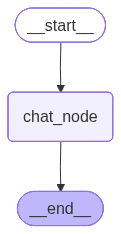

In [54]:
chatbot

In [55]:
thread_id = '1'
while True:



    user_message = input('type here:')

    print('user:' , user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    config = {'configurable': {'thread_id': thread_id}}

    response = chatbot.invoke({'messages': [HumanMessage(content= user_message)]}, config=config)

    print('AI:' , response['messages'][-1].content)

user: hi , what is my name
AI: Hello! I don’t know your name yet. What would you like me to call you?
user: dhruvil
AI: Nice to meet you, Dhruvil! How can I assist you today?
user: what is my nae
AI: Your name is Dhruvil. How can I help you today?
user: exit


In [57]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi , what is my name', additional_kwargs={}, response_metadata={}, id='c8568816-734f-4b3f-9b7c-df5a4643b649'), AIMessage(content='Hello! I don’t know your name yet. What would you like me to call you?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 13, 'total_tokens': 33, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_b6f445fc1c', 'id': 'chatcmpl-DZcJAEqb0qrJs6Pcxe2lHRq1ooyZY', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dd42b-6893-7981-a550-20b3d35d2174-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 20, 'total_tokens': 33, '

In [58]:
from langchain_core.tools import tool

@tool
def get_battery_status():
    """Returns the current Audi battery percentage and range."""
    # Your manual logic here
    return {"battery": "78%", "range": "320km"}

@tool
def open_sunroof():
    """Commands the vehicle to open the sunroof."""
    return {"message": "Sunroof opened"}

@tool
def set_temperature(temp: int):
    """Sets the cabin temperature to a specific degree Celsius."""
    return {"message": f"Cabin temperature set to {temp}°C"}

@tool
def get_vehicle_health():
    """Provides a report of tire pressure, brakes, and oil levels."""
    return {"tire_pressure": "Normal", "oil_level": "Optimal"}

# List of tools to be used in the graph
tools = [get_battery_status, open_sunroof, set_temperature, get_vehicle_health]

In [63]:
from langgraph.prebuilt import ToolNode

# This defines the "tools" variable that was missing in your error
tool_node = ToolNode(tools)

In [64]:
# Bind tools to the LLM
llm_with_tools = llm.bind_tools(tools)

def assistant_node(state: Chatstate):
    # The system prompt from your manual code
    sys_msg = SystemMessage(content="""You are a premium Audi in-car assistant. 
    Be concise and proactive. Use tools only when relevant.""")
    
    # Run the LLM with tools
    response = llm_with_tools.invoke([sys_msg] + state["messages"])
    
    # Return the response to be added to history
    return {"messages": [response]}

In [65]:
# Bind tools to the LLM
llm_with_tools = llm.bind_tools(tools)

def assistant_node(state: Chatstate):
    # The system prompt from your manual code
    sys_msg = SystemMessage(content="""You are a premium Audi in-car assistant. 
    Be concise and proactive. Use tools only when relevant.""")
    
    # Run the LLM with tools
    response = llm_with_tools.invoke([sys_msg] + state["messages"])
    
    # Return the response to be added to history
    return {"messages": [response]}

In [66]:
def should_continue(state: Chatstate):
    last_message = state['messages'][-1]
    
    # If the LLM wants to call a tool, go to 'tools' node
    if last_message.tool_calls:
        return "tools"
    
    # Otherwise, finish the conversation
    return END

In [70]:
# 1. Start fresh
workflow = StateGraph(Chatstate)

# 2. Add the nodes
workflow.add_node("assistant", assistant_node)
workflow.add_node("tools", tool_node)

# 3. Define the START
workflow.add_edge(START, "assistant")

# 4. Add the Conditional Edges (The Router)
# This connects the assistant to EITHER tools or END
workflow.add_conditional_edges(
    "assistant",
    should_continue,
    {
        "tools": "tools",  # If should_continue returns "tools", go to tools node
        END: END           # If it returns END, stop
    }
)

# 5. Add the Loop Back (The missing link in your image)
# This sends the tool result back to the brain
workflow.add_edge("tools", "assistant")

# 6. Compile
chatbot = workflow.compile(checkpointer=MemorySaver())

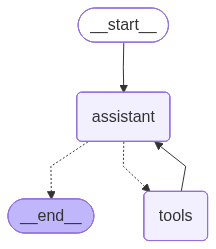

In [71]:
chatbot

In [73]:
def assistant_node(state: Chatstate):
    sys_msg = SystemMessage(content="""
    You are a premium Audi in-car assistant. 
    
    CRITICAL RULES:
    1. You ONLY have access to: battery, temperature, sunroof, and vehicle health.
    2. You CANNOT perform navigation, music, or phone calls.
    3. If a user asks for an unsupported feature (like Navigation), you must 
       politely state: "I'm sorry, I don't have access to navigation yet."
    4. Never pretend to perform an action unless you are calling a tool.
    
    Be concise and proactive within these limits.
    """)
    
    # Run the LLM with the restricted prompt
    response = llm_with_tools.invoke([sys_msg] + state["messages"])
    return {"messages": [response]}

In [74]:
import uuid
from langchain_core.messages import HumanMessage

# 1. Unique ID for this specific car/session
config = {"configurable": {"thread_id": "audi_session_001"}}

print("Audi Assistant Online. (Type 'quit' to exit)")

while True:
    user_input = input("\nDriver: ")
    
    if user_input.lower() in ["quit", "exit", "q"]:
        break

    # 2. Run the graph
    # LangGraph will handle the Assistant -> Tools -> Assistant loop automatically
    output = chatbot.invoke(
        {"messages": [HumanMessage(content=user_input)]}, 
        config=config
    )

    # 3. Print the final message from the history
    # The last message is the Assistant's final response after all tool calls
    print(f"Assistant: {output['messages'][-1].content}")

Audi Assistant Online. (Type 'quit' to exit)
Assistant: Hello again! How can I assist you further with your Audi?
Assistant: Munich is already set as your destination. Would you like me to start guidance or adjust any preferences for your trip?
